In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../data/mutual_funds.db")

In [3]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,fund_master
1,nav_history
2,aum
3,sip
4,category
5,folio
6,performance
7,transactions
8,portfolio
9,benchmark


In [4]:
fund_master = pd.read_sql_query("SELECT * FROM fund_master", conn)

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


In [6]:
fund_master.describe()

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
count,40.000000,40.000000,40.000000,40.0,40.000000
mean,120247.000000,1.237000,0.812500,500.0,1277.500000
std,14534.998667,0.386584,0.387091,0.0,1082.847031
min,100016.000000,0.550000,0.000000,500.0,100.000000
25%,118632.750000,0.787500,1.000000,500.0,1000.000000
50%,119551.500000,1.425000,1.000000,500.0,1000.000000
75%,120842.250000,1.540000,1.000000,500.0,1000.000000
max,149324.000000,1.640000,1.000000,500.0,5000.000000


In [7]:
category_counts = fund_master["category"].value_counts()

category_counts

category
Equity    34
Debt       6
Name: count, dtype: int64

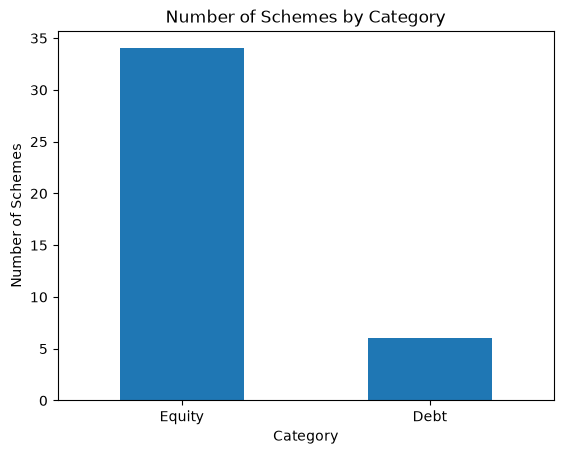

In [8]:
category_counts.plot(kind="bar", title="Number of Schemes by Category")

plt.xlabel("Category")
plt.ylabel("Number of Schemes")
plt.xticks(rotation=0)
plt.show()

In [9]:
fund_house_counts = fund_master["fund_house"].value_counts()

fund_house_counts

fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64

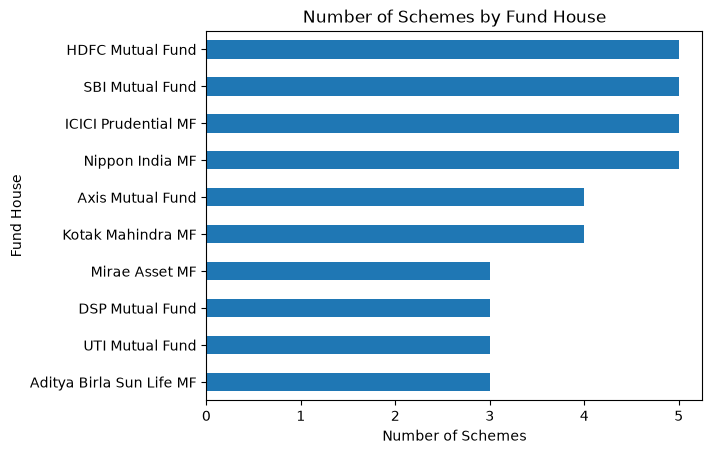

In [10]:
fund_house_counts.sort_values().plot(
    kind="barh",
    title="Number of Schemes by Fund House"
)

plt.xlabel("Number of Schemes")
plt.ylabel("Fund House")
plt.show()

In [11]:
performance = pd.read_sql_query("SELECT * FROM performance", conn)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [12]:
category_returns = (
    performance.groupby("category")["return_1yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

category_returns

category
Small Cap          22.258333
Value              16.670000
Flexi Cap          16.585000
Mid Cap            15.978571
Large & Mid Cap    14.910000
Index              13.760000
Large Cap          13.724286
ELSS               11.160000
Index/ETF          10.140000
Short Duration      6.830000
Liquid              6.443333
Gilt                5.765000
Name: return_1yr_pct, dtype: float64

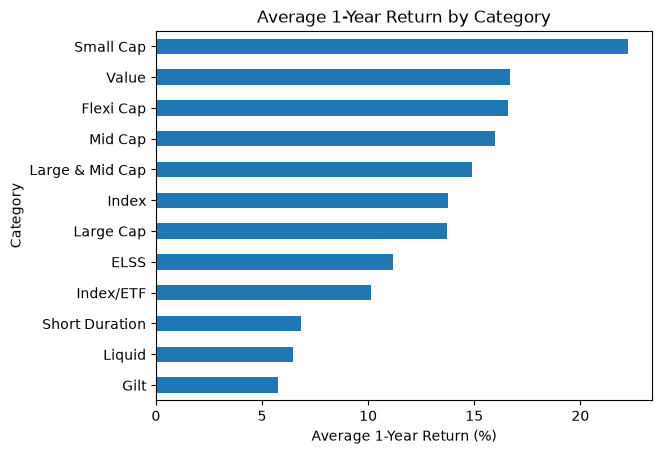

In [13]:
category_returns.sort_values().plot(
    kind="barh",
    title="Average 1-Year Return by Category"
)

plt.xlabel("Average 1-Year Return (%)")
plt.ylabel("Category")
plt.show()

In [14]:
risk_counts = performance["risk_grade"].value_counts()

risk_counts

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

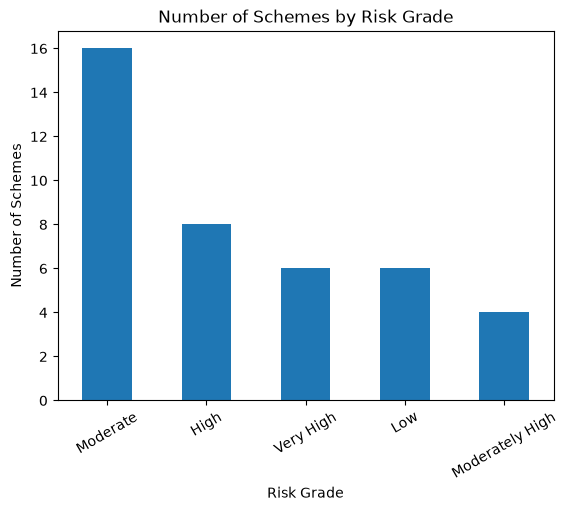

In [15]:
risk_counts.plot(
    kind="bar",
    title="Number of Schemes by Risk Grade"
)

plt.xlabel("Risk Grade")
plt.ylabel("Number of Schemes")
plt.xticks(rotation=30)
plt.show()

In [16]:
return_risk = performance[
    ["scheme_name", "return_1yr_pct", "risk_grade", "sharpe_ratio"]
].sort_values(
    "return_1yr_pct",
    ascending=False
)

return_risk.head(10)

,scheme_name,return_1yr_pct,risk_grade,sharpe_ratio
29,ABSL Small Cap Fund - Regular - Growth,24.93,Very High,0.90
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,Very High,0.94
27,Axis Small Cap Fund - Regular - Growth,21.97,Very High,0.84
17,Nippon India Small Cap Fund - Regular - Growth,21.30,Very High,0.81
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,Very High,0.93
39,DSP Small Cap Fund - Regular - Growth,20.20,Very High,0.80
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,19.98,High,0.80
33,UTI Flexi Cap Fund - Regular - Growth,17.43,Moderately High,0.96
21,Kotak Emerging Equity Fund - Regular - Growth,17.12,High,0.96
13,ICICI Pru Value Discovery Fund - Regular - Growth,16.67,Moderately High,0.98


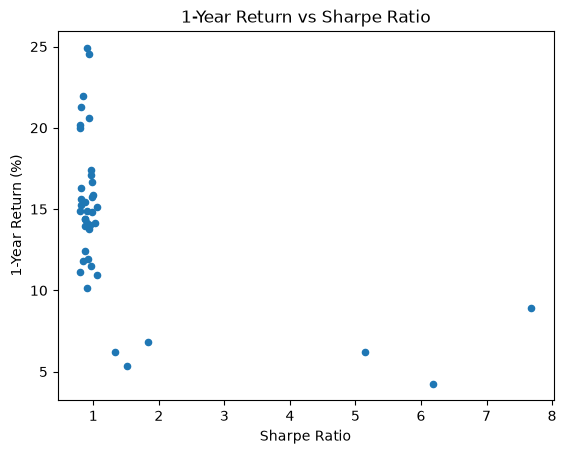

In [17]:
performance.plot(
    kind="scatter",
    x="sharpe_ratio",
    y="return_1yr_pct",
    title="1-Year Return vs Sharpe Ratio"
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("1-Year Return (%)")
plt.show()

In [18]:
sip = pd.read_sql_query(
    "SELECT * FROM sip ORDER BY month",
    conn
)

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


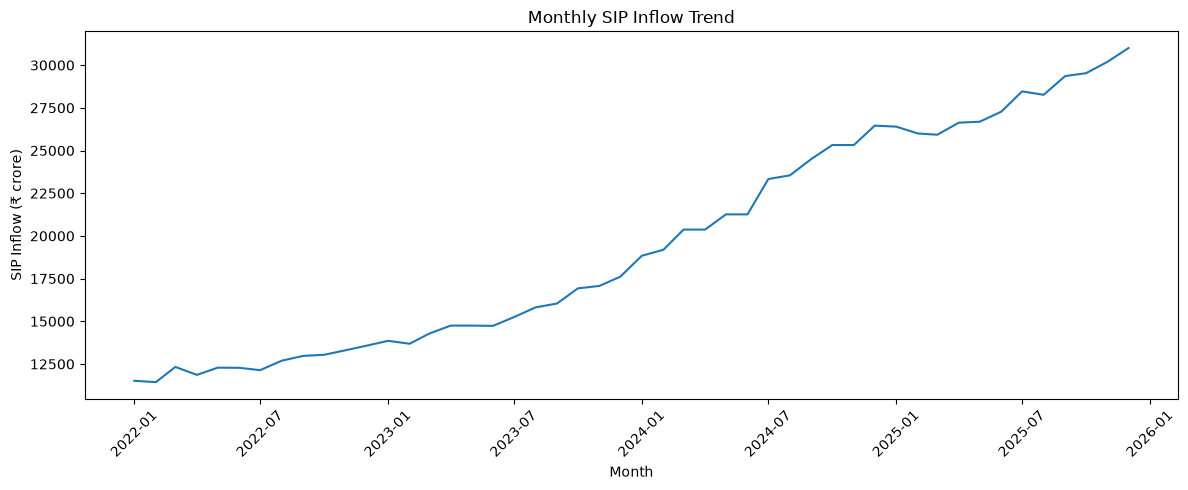

In [19]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12, 5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
sip_summary = {
    "Average SIP Inflow": sip["sip_inflow_crore"].mean(),
    "Highest SIP Inflow": sip["sip_inflow_crore"].max(),
    "Lowest SIP Inflow": sip["sip_inflow_crore"].min()
}

sip_summary

{'Average SIP Inflow': np.float64(19577.520833333332),
 'Highest SIP Inflow': np.int64(31002),
 'Lowest SIP Inflow': np.int64(11438)}

In [21]:
sip_growth = sip.dropna(subset=["yoy_growth_pct"])

sip_growth[["month", "yoy_growth_pct"]].head(10)

,month,yoy_growth_pct
12,2023-01-01,20.31
13,2023-02-01,19.66
14,2023-03-01,15.80
15,2023-04-01,24.33
16,2023-05-01,20.05
17,2023-06-01,20.02
18,2023-07-01,25.58
19,2023-08-01,24.58
20,2023-09-01,23.63
21,2023-10-01,29.82


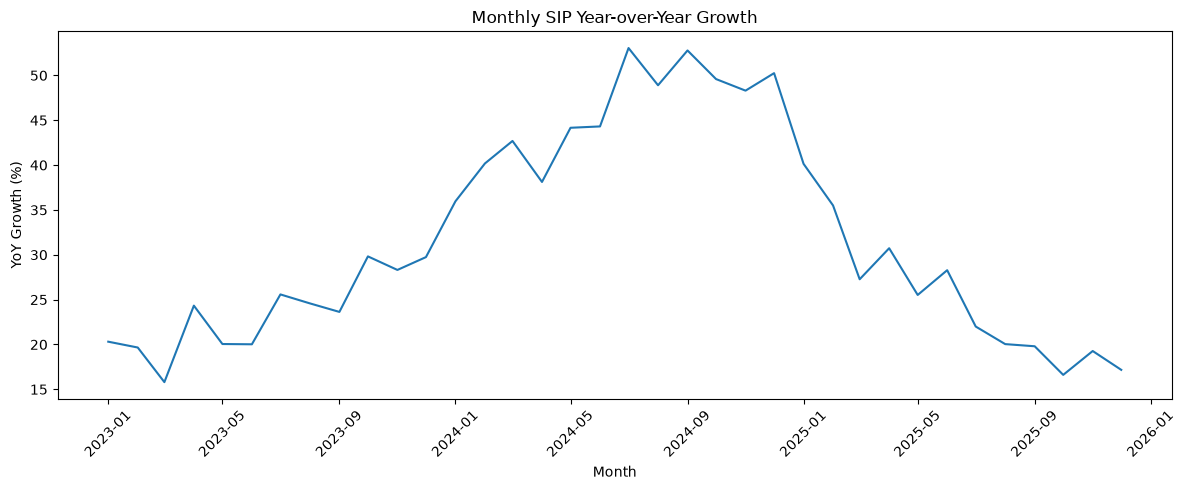

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    sip_growth["month"],
    sip_growth["yoy_growth_pct"]
)

plt.title("Monthly SIP Year-over-Year Growth")
plt.xlabel("Month")
plt.ylabel("YoY Growth (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
aum = pd.read_sql_query(
    "SELECT * FROM aum",
    conn
)

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [24]:
aum_by_fund_house = (
    aum.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

aum_by_fund_house

fund_house
SBI Mutual Fund             8491000
ICICI Prudential MF         6293000
HDFC Mutual Fund            5732000
Nippon India MF             3909000
Kotak Mahindra MF           3502000
Aditya Birla Sun Life MF    3077000
UTI Mutual Fund             2681000
Axis Mutual Fund            2521000
Mirae Asset MF              1561000
DSP Mutual Fund             1409000
Name: aum_crore, dtype: int64

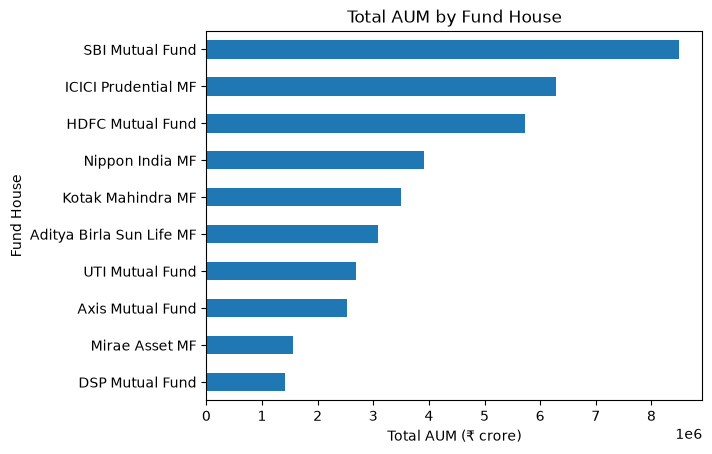

In [25]:
aum_by_fund_house.sort_values().plot(
    kind="barh",
    title="Total AUM by Fund House"
)

plt.xlabel("Total AUM (₹ crore)")
plt.ylabel("Fund House")
plt.show()

In [26]:
category_aum = (
    performance.groupby("category")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

category_aum

category
Large Cap          324466
Mid Cap            198984
Small Cap          197232
Liquid             105734
Gilt                54131
Flexi Cap           52924
Large & Mid Cap     49046
Short Duration      27953
Index/ETF           20284
Index                7350
ELSS                 2989
Value                2571
Name: aum_crore, dtype: int64

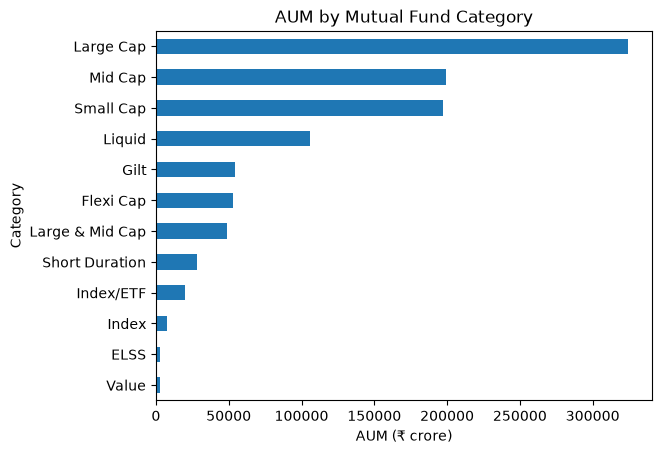

In [27]:
category_aum.sort_values().plot(
    kind="barh",
    title="AUM by Mutual Fund Category"
)

plt.xlabel("AUM (₹ crore)")
plt.ylabel("Category")
plt.show()

In [28]:
top_10_returns = (
    performance[
        ["scheme_name", "fund_house", "category", "return_1yr_pct", "risk_grade"]
    ]
    .sort_values("return_1yr_pct", ascending=False)
    .head(10)
)

top_10_returns

,scheme_name,fund_house,category,return_1yr_pct,risk_grade
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,24.93,Very High
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,24.56,Very High
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,21.97,Very High
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,21.30,Very High
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,20.59,Very High
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,20.20,Very High
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,19.98,High
33,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,17.43,Moderately High
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,17.12,High
13,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Value,16.67,Moderately High


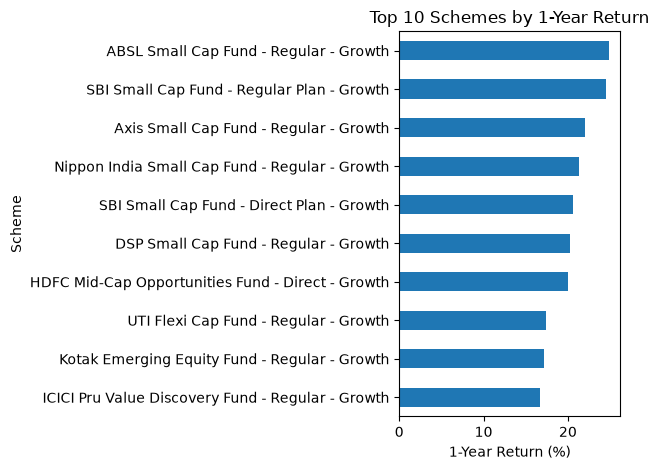

In [29]:
top_10_returns_plot = top_10_returns.sort_values("return_1yr_pct")

top_10_returns_plot.plot(
    x="scheme_name",
    y="return_1yr_pct",
    kind="barh",
    legend=False,
    title="Top 10 Schemes by 1-Year Return"
)

plt.xlabel("1-Year Return (%)")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

In [30]:
nav = pd.read_sql_query(
    "SELECT * FROM nav_history ORDER BY date",
    conn
)

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119552,2022-01-03,58.4174
2,119598,2022-01-03,89.8738
3,119599,2022-01-03,96.4565
4,119120,2022-01-03,42.1391


In [31]:
nav["date"] = pd.to_datetime(nav["date"])

nav_change = (
    nav.sort_values("date")
    .groupby("amfi_code")
    .agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )
)

nav_change["nav_change_pct"] = (
    (nav_change["end_nav"] - nav_change["start_nav"])
    / nav_change["start_nav"]
) * 100

nav_change.sort_values("nav_change_pct", ascending=False).head(10)

,start_nav,end_nav,nav_change_pct
amfi_code,,,
120505,135.8720,473.7640,248.684056
119598,89.8738,309.2050,244.043537
149324,81.6814,279.7511,242.490579
148569,28.8620,97.7435,238.658097
148567,70.2514,230.2708,227.781083
120843,49.9131,163.2397,227.047809
100033,107.3758,342.0072,218.514228
149323,78.4622,245.3651,212.717589
119094,68.3023,203.8581,198.464473


In [32]:
nav_change_named = (
    nav_change.reset_index()
    .merge(
        fund_master[["amfi_code", "scheme_name"]],
        on="amfi_code",
        how="left"
    )
    .sort_values("nav_change_pct", ascending=False)
)

nav_change_named[
    ["amfi_code", "scheme_name", "start_nav", "end_nav", "nav_change_pct"]
].head(10)

,amfi_code,scheme_name,start_nav,end_nav,nav_change_pct
25,120505,ICICI Pru Midcap Fund - Regular - Growth,135.8720,473.7640,248.684056
21,119598,SBI Small Cap Fund - Regular Plan - Growth,89.8738,309.2050,244.043537
39,149324,DSP Small Cap Fund - Regular - Growth,81.6814,279.7511,242.490579
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.8620,97.7435,238.658097
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,70.2514,230.2708,227.781083
30,120843,Kotak Flexicap Fund - Regular - Growth,49.9131,163.2397,227.047809
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,107.3758,342.0072,218.514228
38,149323,DSP Midcap Fund - Regular - Growth,78.4622,245.3651,212.717589
16,119094,Axis Midcap Fund - Regular - Growth,68.3023,203.8581,198.464473
19,119551,SBI Bluechip Fund - Regular Plan - Growth,54.3856,149.3216,174.560913


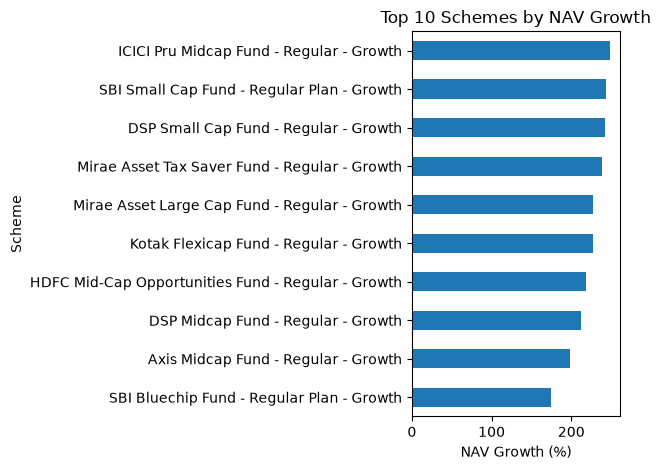

In [33]:
nav_top10 = nav_change_named.head(10).sort_values("nav_change_pct")

nav_top10.plot(
    x="scheme_name",
    y="nav_change_pct",
    kind="barh",
    legend=False,
    title="Top 10 Schemes by NAV Growth"
)

plt.xlabel("NAV Growth (%)")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()